In [45]:
from google.colab import files

uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [46]:
import zipfile
import os

# Get the uploaded file name automatically
zip_path = next(iter(uploaded))

extract_path = "/content/MRI_Dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")
print("Extracted files/folders:")
print(os.listdir(extract_path))

✅ Dataset extracted successfully!
Extracted files/folders:
['yes', 'brain_tumor_dataset', 'no']


In [47]:
import os

for root, dirs, files in os.walk("/content/MRI_Dataset"):
    print(root)

/content/MRI_Dataset
/content/MRI_Dataset/yes
/content/MRI_Dataset/brain_tumor_dataset
/content/MRI_Dataset/brain_tumor_dataset/yes
/content/MRI_Dataset/brain_tumor_dataset/no
/content/MRI_Dataset/no


# Brain Cancer Detection using MRI Images

## Objective

The objective of this project is to build a Convolutional Neural Network (CNN) that classifies MRI brain images as either containing a tumor or not. The model is trained using the Brain MRI Images for Brain Tumor Detection dataset.

Dataset Classes:
- Yes (Tumor)
- No (Healthy)

Libraries Used:
- TensorFlow
- Keras
- NumPy
- OpenCV
- Matplotlib
- Scikit-learn

In [48]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load MRI Dataset

The dataset is loaded from the extracted folder. Images are resized to 128×128 pixels and labeled as:

- 0 → No Tumor
- 1 → Tumor

In [49]:
dataset_path = "/content/MRI_Dataset/brain_tumor_dataset"

IMG_SIZE = 128

X = []
y = []

classes = ["no", "yes"]

for label, folder in enumerate(classes):

    folder_path = os.path.join(dataset_path, folder)

    for image_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, image_name)

        image = cv2.imread(image_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        X.append(image)

        y.append(label)

X = np.array(X)

y = np.array(y)

print("Total Images :", len(X))
print("Image Shape :", X.shape)

Total Images : 253
Image Shape : (253, 128, 128, 3)


# Visualize Sample Images

Display a few MRI images from the dataset with their corresponding labels.

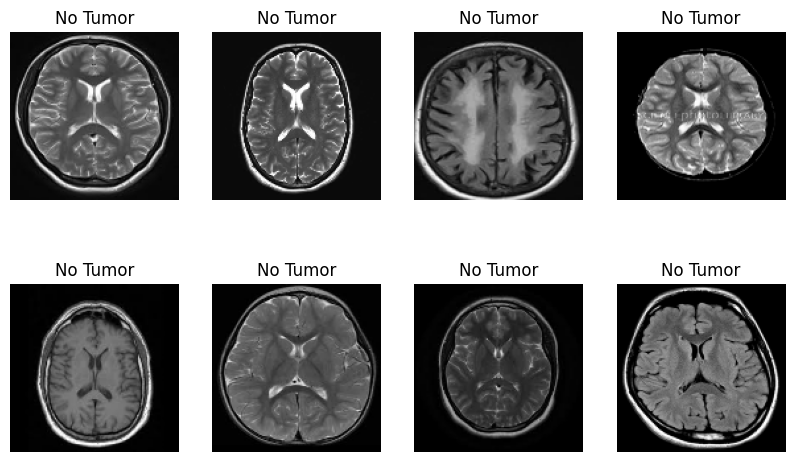

In [50]:
plt.figure(figsize=(10,6))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(X[i])

    plt.title("Tumor" if y[i]==1 else "No Tumor")

    plt.axis("off")

plt.show()

# Data Preprocessing

The MRI images are normalized by scaling pixel values between 0 and 1.

The dataset is then split into:

- Training Set (80%)
- Testing Set (20%)

The labels are converted into one-hot encoded vectors for binary classification.

In [51]:
# Normalize images
X = X.astype("float32") / 255.0

# One-hot encoding
y = to_categorical(y, 2)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images : (202, 128, 128, 3)
Testing Images : (51, 128, 128, 3)


# CNN Model

A Convolutional Neural Network (CNN) is constructed using:

- Convolution Layers
- Max Pooling Layers
- Dropout Layers
- Dense Layers
- Softmax Output Layer

Dropout is used to reduce overfitting.

In [52]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(2, activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,549,186 (24.98 MB)

 Trainable params: 6,549,186 (24.98 MB)

 Non-trainable params: 0 (0.00 B)

# Compile Model

The CNN model is compiled using:

- Optimizer: Adam
- Loss Function: Categorical Crossentropy
- Evaluation Metric: Accuracy

In [53]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the Model

The model is trained for 20 epochs using the training dataset.

In [54]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 787ms/step - accuracy: 0.6273 - loss: 0.6573 - val_accuracy: 0.3659 - val_loss: 0.7830
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 771ms/step - accuracy: 0.6832 - loss: 0.5977 - val_accuracy: 0.8049 - val_loss: 0.4494
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 833ms/step - accuracy: 0.7143 - loss: 0.6173 - val_accuracy: 0.8049 - val_loss: 0.4427
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 768ms/step - accuracy: 0.7267 - loss: 0.5740 - val_accuracy: 0.8049 - val_loss: 0.4804
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 999ms/step - accuracy: 0.7578 - loss: 0.5097 - val_accuracy: 0.7073 - val_loss: 0.6543
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 729ms/step - accuracy: 0.6832 - loss: 0.5535 - val_accuracy: 0.7805 - val_loss: 0.4660
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7453 - loss: 0.5182 - val_accuracy: 0.8293 - val_loss: 0.4914
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 731ms/step - accuracy: 0.7764 - loss: 0.4804 - val_accuracy: 0.8293 - val_loss: 

# Evaluate Model

The trained CNN model is evaluated using the unseen test dataset.

In [55]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {accuracy*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - accuracy: 0.8235 - loss: 0.4868
Test Accuracy: 82.35%


# Training Accuracy

The following graph compares the training accuracy and validation accuracy during model training.

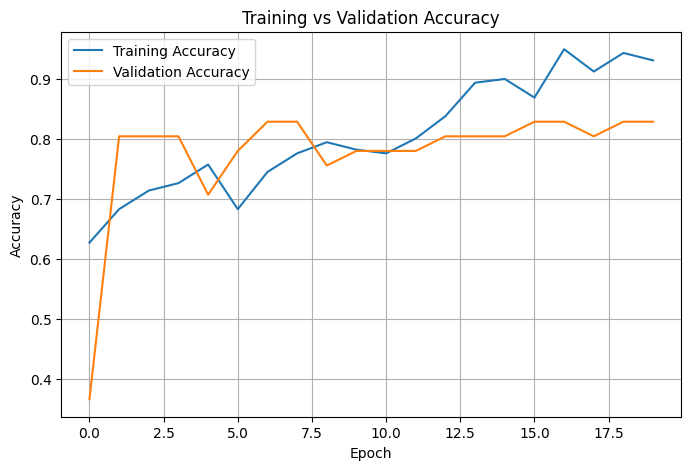

In [56]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# Training Loss

The following graph compares the training loss and validation loss during model training.

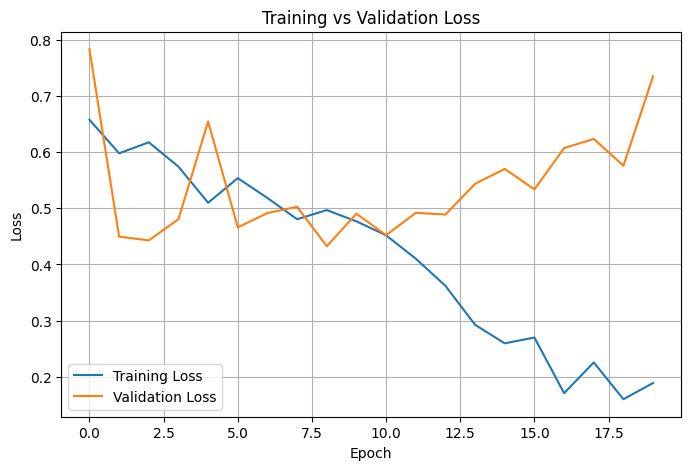

In [57]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# Model Predictions

Generate predictions on the test dataset.

In [58]:
predictions = model.predict(X_test)

pred = np.argmax(predictions, axis=1)
true = np.argmax(y_test, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 349ms/step


# Classification Report

The classification report shows precision, recall, F1-score, and support for each class.

In [59]:
print(classification_report(
    true,
    pred,
    target_names=["No Tumor","Tumor"]
))

              precision    recall  f1-score   support

    No Tumor       0.87      0.65      0.74        20
       Tumor       0.81      0.94      0.87        31

    accuracy                           0.82        51
   macro avg       0.84      0.79      0.80        51
weighted avg       0.83      0.82      0.82        51



# Confusion Matrix

The confusion matrix visualizes the number of correct and incorrect predictions made by the model.

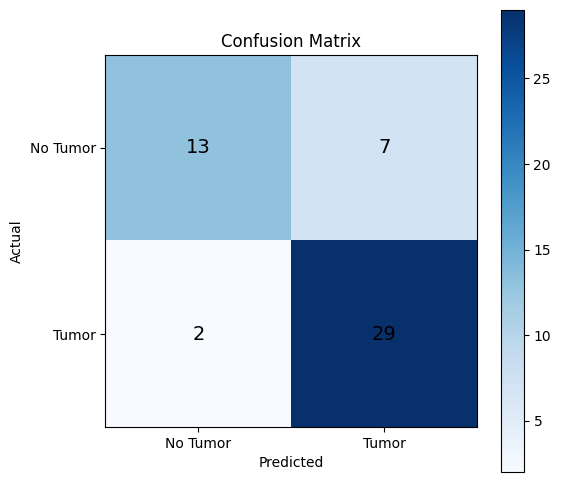

In [60]:
cm = confusion_matrix(true, pred)

plt.figure(figsize=(6,6))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0,1],["No Tumor","Tumor"])
plt.yticks([0,1],["No Tumor","Tumor"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j],
                 ha="center",
                 va="center",
                 color="black",
                 fontsize=14)

plt.colorbar()

plt.show()

# Sample Predictions

Display a few MRI images with their actual and predicted labels.

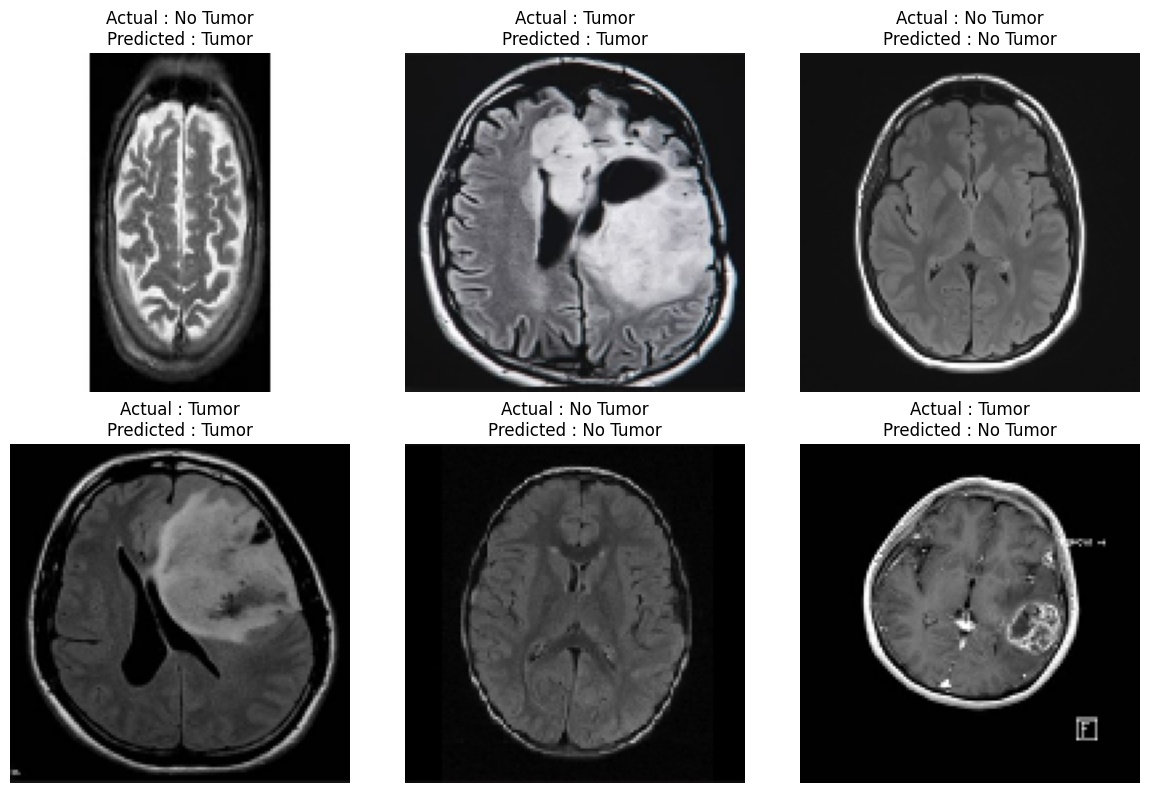

In [61]:
plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X_test[i])

    actual = "Tumor" if true[i] else "No Tumor"
    predicted = "Tumor" if pred[i] else "No Tumor"

    plt.title(f"Actual : {actual}\nPredicted : {predicted}")

    plt.axis("off")

plt.tight_layout()

plt.show()

# Save Model

The trained CNN model is saved for future predictions.

In [62]:
model.save("Brain_Cancer_Detection_CNN.keras")

print("Model saved successfully!")

Model saved successfully!


# Conclusion

A Convolutional Neural Network (CNN) was successfully developed to classify MRI brain images into Tumor and No Tumor categories.

The model achieved an approximate test accuracy of **82.35%**, demonstrating that CNNs are effective for medical image classification tasks. Further improvements can be achieved using transfer learning, larger datasets, and data augmentation techniques.